# **Etapa 2 - Iplementação do problema**

## Problema escolhido: **Problema da mochila (Knapsack)**:
Dado um conjunto de itens com pesos e valores, selecionar quais incluir na mochila para maximizar o valor total sem exceder a capacidade máxima de peso.
## Algoritmo escolhido: **QAOA (Quantum Approximate Optimization Algorithm):**
Algoritmo híbrido quântico-clássico que codifica o problema como um Hamiltoniano de custo e usa camadas alternadas de operadores quânticos para encontrar soluções aproximadas

In [ ]:
!pip install pennylane

In [ ]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

# Definição do problema da mochila no formato QUBO

O problema da mochila é convertido para o formato QUBO (Quadratic Unconstrained Binary Optimization), necessário para rodar no QAOA. A conversão produz:

- **h** — coeficientes diagonais: `hi = λ*(wi² - 2*wi*W)/4 - vi/2`
- **J** — coeficientes de interação entre pares: `Jij = λ*wi*wj/2`

In [ ]:
def definir_qubo(itens, capacidade, lam=1.0):
    n      = len(itens)
    nomes  = [item["nome"]  for item in itens]
    pesos  = [item["peso"]  for item in itens]
    valores = [item["valor"] for item in itens]

    h = [lam * (pesos[i]**2 - 2*pesos[i]*capacidade) / 4 - valores[i]/2 for i in range(n)]

    J = {}
    for i in range(n):
        for j in range(i+1, n):
            J[(i, j)] = lam * pesos[i] * pesos[j] / 2

    print("Hamiltoniano de Custo")
    print(f"Itens          : {nomes}")
    print(f"Pesos          : {pesos}")
    print(f"Valores        : {valores}")
    print(f"Capacidade     : {capacidade}")
    print(f"λ              : {lam}")
    print(f"h (diagonais)  : {[round(hi, 2) for hi in h]}")
    print(f"J (interações) : { {k: round(val,2) for k,val in J.items()} }")

    return nomes, pesos, valores, h, J


In [ ]:
itens = [
    {"nome": "Notebook", "peso": 3, "valor": 10},
    {"nome": "Câmera",   "peso": 2, "valor": 8},
    {"nome": "Livro",    "peso": 1, "valor": 4},
    {"nome": "Garrafa",  "peso": 2, "valor": 5},
]
capacidade = 8
lam        = 1.0

nomes, pesos, valores, h, J = definir_qubo(itens, capacidade=capacidade, lam=lam)

Hamiltoniano de Custo
Itens          : ['Notebook', 'Câmera', 'Livro', 'Garrafa']
Pesos          : [3, 2, 1, 2]
Valores        : [10, 8, 4, 5]
Capacidade     : 8
λ              : 1.0
h (diagonais)  : [-14.75, -11.0, -5.75, -9.5]
J (interações) : {(0, 1): 3.0, (0, 2): 1.5, (0, 3): 3.0, (1, 2): 1.0, (1, 3): 2.0, (2, 3): 1.0}


## 3. Circuito QAOA

O QAOA aplica, em `p` camadas, dois operadores alternados:

- **Uc(γ)** — operador de custo: marca cada estado com uma fase proporcional ao seu custo
- **Um(β)** — operador de mistura: rotaciona todos os qubits no eixo X, gerando interferência entre os estados

Ao final, o circuito retorna o valor esperado `⟨HC⟩`, que o otimizador clássico minimiza ajustando γ e β.

In [ ]:
class CircuitoQAOA:

    def __init__(self, h, J, num_camadas=2):
        self.h           = h
        self.J           = J
        self.num_camadas = num_camadas
        self.num_qubits  = len(h)

        self.dispositivo = qml.device("default.qubit", wires=self.num_qubits)
        self.circuito    = qml.QNode(self._fn_circuito, self.dispositivo)
        self.amostrar    = qml.QNode(self._fn_amostrar, self.dispositivo)

    def _operador_custo(self, gamma):
        """Operador de custo Uc(γ)."""
        for i in range(self.num_qubits):
            qml.RZ(2 * gamma * self.h[i], wires=i)
        for (i, j), Jij in self.J.items():
            qml.CNOT(wires=[i, j])
            qml.RZ(2 * gamma * Jij, wires=j)
            qml.CNOT(wires=[i, j])

    def _operador_mistura(self, beta):
        """Operador de mistura Um(β)."""
        for i in range(self.num_qubits):
            qml.RX(2 * beta, wires=i)

    def _fn_circuito(self, parametros):
        """Circuito completo — retorna ⟨HC⟩."""
        gammas = parametros[0]
        betas  = parametros[1]

        for i in range(self.num_qubits):
            qml.Hadamard(wires=i)

        for camada in range(self.num_camadas):
            self._operador_custo(gammas[camada])
            self._operador_mistura(betas[camada])

        coeficientes = list(self.h) + [Jij for Jij in self.J.values()]
        observaveis  = ([qml.PauliZ(i) for i in range(self.num_qubits)]
                        + [qml.PauliZ(i) @ qml.PauliZ(j) for (i, j) in self.J.keys()])
        hamiltoniano = qml.Hamiltonian(coeficientes, observaveis)
        return qml.expval(hamiltoniano)

    def _fn_amostrar(self, parametros):
        """Retorna P(|x⟩) para todos os estados após otimização."""
        gammas = parametros[0]
        betas  = parametros[1]

        for i in range(self.num_qubits):
            qml.Hadamard(wires=i)

        for camada in range(self.num_camadas):
            self._operador_custo(gammas[camada])
            self._operador_mistura(betas[camada])

        return qml.probs(wires=range(self.num_qubits))

    def otimizar(self, num_passos=100, taxa_aprendizado=0.1, semente=42):
        """Otimiza γ e β via gradiente descendente."""
        np.random.seed(semente)

        parametros = np.array([
            np.random.uniform(0, np.pi, self.num_camadas),
            np.random.uniform(0, np.pi, self.num_camadas)
        ], requires_grad=True)

        otimizador = qml.GradientDescentOptimizer(stepsize=taxa_aprendizado)
        custos = []

        print("\n Otimizando γ e β ")
        for passo in range(num_passos):
            parametros, custo = otimizador.step_and_cost(self.circuito, parametros)
            custos.append(float(custo))
            if passo % 20 == 0:
                print(f"Passo {passo:3d} | ⟨HC⟩ = {custo:.4f} | "
                      f"γ={[round(g,3) for g in parametros[0].tolist()]} | "
                      f"β={[round(b,3) for b in parametros[1].tolist()]}")

        print(f"\nParâmetros finais:")
        print(f"  γ = {[round(g, 4) for g in parametros[0].tolist()]}")
        print(f"  β = {[round(b, 4) for b in parametros[1].tolist()]}")

        return parametros, custos

In [ ]:
# Otimização dos parâmetros

qaoa = CircuitoQAOA(h, J, num_camadas=2)
parametros, custos = qaoa.otimizar(num_passos=100, taxa_aprendizado=0.1)


 Otimizando γ e β 
Passo   0 | ⟨HC⟩ = -1.5828 | γ=[2.994, -11.361] | β=[2.278, 1.924]
Passo  20 | ⟨HC⟩ = -9.8183 | γ=[29.298, -24.326] | β=[3.28, -0.428]
Passo  40 | ⟨HC⟩ = -10.8769 | γ=[111.229, -25.998] | β=[9.83, 0.289]
Passo  60 | ⟨HC⟩ = -8.6718 | γ=[223.767, 61.185] | β=[12.57, 4.567]
Passo  80 | ⟨HC⟩ = 9.5217 | γ=[127.475, 10.533] | β=[14.671, 5.459]

Parâmetros finais:
  γ = [182.6972, 23.7008]
  β = [10.2926, -0.5124]


In [ ]:

probabilidades  = qaoa.amostrar(parametros)
num_qubits      = qaoa.num_qubits
melhor_prob    = 0
melhor_solucao = None
melhor_valida_prob    = 0
melhor_valida_solucao = None

## 5. Medição e Resultado

Com os parâmetros otimizados, medimos as probabilidades de cada estado e identificamos a solução mais provável.

In [ ]:
for i, prob in enumerate(probabilidades):
    bits         = format(i, f'0{num_qubits}b')
    selecionados = [nomes[j] for j in range(num_qubits) if bits[j] == '1']
    peso_total   = sum(pesos[j] for j in range(num_qubits) if bits[j] == '1')
    valor_total  = sum(valores[j] for j in range(num_qubits) if bits[j] == '1')
    valido       = peso_total <= capacidade

    print(f"|{bits}⟩ {'--VÁLIDO--' if valido else '--INVÁLIDO--'} "
          f"Itens={selecionados} Peso={peso_total} Valor={valor_total} Prob={prob:.3f}")

    if prob > melhor_prob:
        melhor_prob    = prob
        melhor_solucao = (bits, selecionados, peso_total, valor_total)

    if valido and prob > melhor_valida_prob:
        melhor_valida_prob    = prob
        melhor_valida_solucao = (bits, selecionados, peso_total, valor_total)

print(f"\nSolução mais provável (geral): |{melhor_solucao[0]}⟩ "
      f"- Valor={melhor_solucao[3]}")
print(f"Solução válida mais provável:  |{melhor_valida_solucao[0]}⟩ "
      f"- Valor={melhor_valida_solucao[3]}")

|0000⟩ --VÁLIDO-- Itens=[] Peso=0 Valor=0 Prob=0.026
|0001⟩ --VÁLIDO-- Itens=['Garrafa'] Peso=2 Valor=5 Prob=0.138
|0010⟩ --VÁLIDO-- Itens=['Livro'] Peso=1 Valor=4 Prob=0.070
|0011⟩ --VÁLIDO-- Itens=['Livro', 'Garrafa'] Peso=3 Valor=9 Prob=0.012
|0100⟩ --VÁLIDO-- Itens=['Câmera'] Peso=2 Valor=8 Prob=0.098
|0101⟩ --VÁLIDO-- Itens=['Câmera', 'Garrafa'] Peso=4 Valor=13 Prob=0.010
|0110⟩ --VÁLIDO-- Itens=['Câmera', 'Livro'] Peso=3 Valor=12 Prob=0.007
|0111⟩ --VÁLIDO-- Itens=['Câmera', 'Livro', 'Garrafa'] Peso=5 Valor=17 Prob=0.154
|1000⟩ --VÁLIDO-- Itens=['Notebook'] Peso=3 Valor=10 Prob=0.143
|1001⟩ --VÁLIDO-- Itens=['Notebook', 'Garrafa'] Peso=5 Valor=15 Prob=0.000
|1010⟩ --VÁLIDO-- Itens=['Notebook', 'Livro'] Peso=4 Valor=14 Prob=0.105
|1011⟩ --VÁLIDO-- Itens=['Notebook', 'Livro', 'Garrafa'] Peso=6 Valor=19 Prob=0.042
|1100⟩ --VÁLIDO-- Itens=['Notebook', 'Câmera'] Peso=5 Valor=18 Prob=0.001
|1101⟩ --VÁLIDO-- Itens=['Notebook', 'Câmera', 'Garrafa'] Peso=7 Valor=23 Prob=0.017
|1110⟩ --VÁL

##Visualização em gráficos:

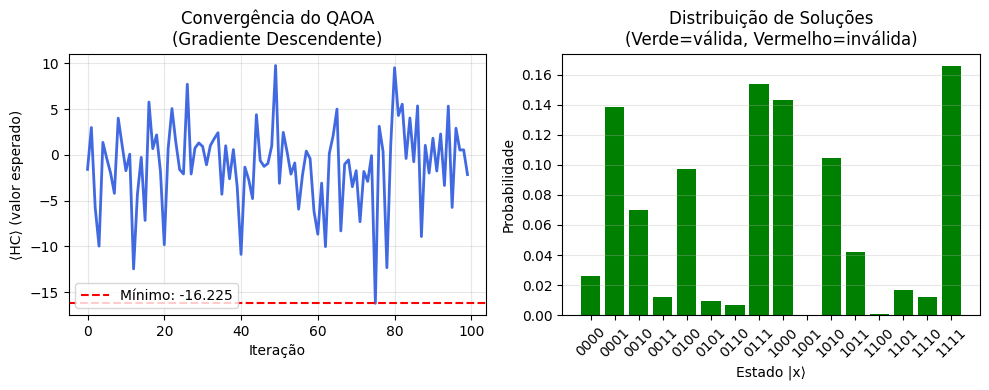

In [ ]:
fig, (eixo1, eixo2) = plt.subplots(1, 2, figsize=(10, 4))

# Convergência do otimizador
eixo1.plot(custos, color='royalblue', linewidth=2)
eixo1.axhline(y=min(custos), color='red', linestyle='--', label=f'Mínimo: {min(custos):.3f}')
eixo1.set_xlabel('Iteração')
eixo1.set_ylabel('⟨HC⟩ (valor esperado)')
eixo1.set_title('Convergência do QAOA\n(Gradiente Descendente)')
eixo1.grid(True, alpha=0.3)
eixo1.legend()

# Distribuição de probabilidade dos estados
cores = ['green' if sum(pesos[j] for j in range(num_qubits)
                        if format(i, f'0{num_qubits}b')[j] == '1') <= capacidade
         else 'red'
         for i in range(len(probabilidades))]
eixo2.bar([format(i, f'0{num_qubits}b') for i in range(len(probabilidades))], probabilidades, color=cores)
eixo2.set_xlabel('Estado |x⟩')
eixo2.set_ylabel('Probabilidade')
eixo2.set_title('Distribuição de Soluções\n(Verde=válida, Vermelho=inválida)')
eixo2.tick_params(axis='x', rotation=45)
eixo2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Comparação com solução ótima (brute force)

In [ ]:
from itertools import combinations

def solucao_otima_classica(itens, capacidade):
    """Força bruta para encontrar a solução ótima."""
    n = len(itens)
    melhor_valor = 0
    melhor_combo = []

    for r in range(n + 1):
        for combo in combinations(range(n), r):
            peso  = sum(itens[i]["peso"]  for i in combo)
            valor = sum(itens[i]["valor"] for i in combo)
            if peso <= capacidade and valor > melhor_valor:
                melhor_valor = valor
                melhor_combo = [itens[i]["nome"] for i in combo]

    return melhor_combo, melhor_valor

combo_otimo, valor_otimo = solucao_otima_classica(itens, capacidade)
print(f"Ótimo clássico: Itens={combo_otimo}, Valor={valor_otimo}")
print(f"Aproximação QAOA: {melhor_valida_solucao[3] / valor_otimo * 100:.1f}% do ótimo")

Ótimo clássico: Itens=['Notebook', 'Câmera', 'Livro', 'Garrafa'], Valor=27
Aproximação QAOA: 100.0% do ótimo
